In [105]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score
from sklearn.svm import SVC, LinearSVC
import re 
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [106]:
df = pd.read_csv("winter_project_2026/development.csv")

category_map = {
    0: "International News",
    1: "Business",
    2: "Technology",
    3: "Entertainment",
    4: "Sports",
    5: "General News",
    6: "Health"
}

df.dropna(inplace=True)

df.dtypes

Id            int64
source       object
title        object
article      object
page_rank     int64
timestamp    object
label         int64
dtype: object

In [ ]:
def clean_text_without_url(text):
    if not isinstance(text, str):
        return ""

    # capturing alt captions from HTML before stripping tags
    captions = " ".join(re.findall(r'alt="([^"]*)"', text))
    captions = re.sub(r'[^a-zA-Z\s]', ' ', captions)

    # removing the URL messages 
    text_no_links = re.sub(r'https?://\S+', ' ', text)

    # remove HTML tags
    text_without_tags = re.sub(r'<[^>]+>', ' ', text_no_links)

    # keep information about money simbols
    text_without_tags = re.sub(
        r'[$€£¥]',
        ' MONEYAMOUNT ',
        text_without_tags
    )

    # this removes punctuation, numbers
    text_final = re.sub(r"[^a-zA-Z\s]", ' ', text_without_tags)

    combined = text_final  + " " + captions

    # extra whitespace removal
    return re.sub(r'\s+', ' ', combined).strip().lower()

clean_text = clean_text_without_url

def cleaner_applyer(df):
    df['title'] = df['title'].fillna('').apply(clean_text)
    df['article'] = df['article'].fillna('').apply(clean_text)
    df['source'] = df['source'].fillna('')
    df['combined_text'] = df['title'] + " " + df['article']
    df['combined_text2'] = df['article'] + ' ' + df['title'] 


from sklearn.base import BaseEstimator, TransformerMixin

class TextCleanerTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self  
    
    def transform(self, X):
        # Creiamo una copia per non modificare il DF originale
        X = X.copy()
            
        cleaner_applyer(X)
        
        return X
    
cleaner = TextCleanerTransformer()

from sklearn.feature_extraction.text import TfidfVectorizer 
from nltk.tokenize import word_tokenize 
from nltk.stem.wordnet import WordNetLemmatizer 
from nltk.corpus import stopwords as sw 
import nltk

class LemmaTokenizerGood(object): 
    def __init__(self): 
        self.lemmatizer = WordNetLemmatizer() 
        self.stop_words = set(sw.words('english'))
    
    def __call__(self, document): 
        lemmas = [] 
        for t in word_tokenize(document): 
            t = t.lower().strip()
            
            if t.isalpha() and t not in self.stop_words and len(t) > 2:
                lemma = self.lemmatizer.lemmatize(t) 
                lemmas.append(lemma)
                
        return lemmas

lemmaTokenizer = LemmaTokenizerGood()   
text_transformer1 = TfidfVectorizer(
    max_features=None, 
    tokenizer=lemmaTokenizer, 
    stop_words=None, 
    ngram_range=(1,2), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True, 
    token_pattern=None, 
    min_df=5, 
    max_df=0.15)    

text_transformer2 = TfidfVectorizer(
    max_features=None,
    stop_words='english', 
    ngram_range=(1,1), 
    sublinear_tf=True, 
    norm='l2', 
    use_idf = True, 
    # token_pattern=None, 
    min_df=5, 
    max_df=0.15)   

# PRIME ANALISI SUL DATASET

In [ ]:
total_records = len(df)

unique_articles = df['article'].nunique()

duplicate_count = df['article'].duplicated().sum()

redundancy_percentage = (duplicate_count / total_records) * 100

print(f"Record totali nel dataset: {total_records}")
print(f"Articoli unici (distinti): {unique_articles}")
print(f"Numero di righe duplicate: {duplicate_count}")
print(f"Tasso di ridondanza: {redundancy_percentage:.2f}%")

# Extra per il report: i duplicati sono distribuiti equamente o sono concentrati in una classe?
dup_by_class = df[df['article'].duplicated(keep=False)]['label'].value_counts()
print("\nDistribuzione dei duplicati per classe (Top 3):")
print(dup_by_class)

--- ANALISI CRITICA DUPLICATI ---
Record totali nel dataset: 79995
Articoli unici (distinti): 74393
Numero di righe duplicate: 5602
Tasso di ridondanza: 7.00%

Distribuzione dei duplicati per classe (Top 3):
label
5    2984
0    1540
1    1428
3    1141
2     685
6     363
4     284
Name: count, dtype: int64


# PULIZIA DA QUESTI DUPLICATI

In [ ]:
remove_short = True
remove_long = False
remove_duplicates = False
remove_duplicates2 = True


if remove_duplicates:
    occurrence_count = df.groupby("article").cumcount()

    mask_keep_first = (occurrence_count == 0)

    total_duplicates_removed = (df.groupby("article")["article"].transform("count") > 1).sum() - mask_keep_first[df.groupby("article")["article"].transform("count") > 1].sum()

    df = df[mask_keep_first].reset_index(drop=True)

    print(f"dup -> {total_duplicates_removed} extra copies removed (1 copy kept)")

if remove_duplicates2:
    len_prima = df.shape[0]
    df = df.drop_duplicates(subset=['article'], keep='first').reset_index(drop=True)
    len_dopo = df.shape[0]
    print(f"dup -> {len_prima - len_dopo} extra copies removed (1 copy kept)")


#rimozioni articoli troppo lunghi
if remove_long:
    lenght = np.array([len(article) for article in df['article']])
    p90_value = np.percentile(lenght, 99.9)
    print(f"max len accepted = {p90_value}")
    mask_lenght = lenght <= p90_value
    filtered_lenght = lenght[mask_lenght]

    # If you want to filter your original DataFrame
    df = df[df['article'].str.len() <= p90_value].reset_index(drop=True)

    print(f"too long -> {(~mask_lenght).sum()} has been removed")

if remove_short:
    mask_len = df['article'].str.len() >= 50
    df = df[mask_len].copy() 
    print(f"too short -> {(~mask_len).sum()} has been removed")

    df = df.reset_index(drop=True)



    

df = df.reset_index(drop = True)


dup -> 5602 extra copies removed (1 copy kept)
too short -> 707 has been removed


# DISTRIBUZIONE DEI LABEL

In [ ]:
import pandas as pd

label_counts = df['label'].value_counts().sort_index()

label_names = label_counts.index.map(category_map)

distribution_table = pd.DataFrame({
    'Class ID': label_counts.index,
    'Category': label_names,
    'Count': label_counts.values,
    'Percentage (%)': (label_counts.values / label_counts.sum() * 100).round(2)
})

distribution_table


,Class ID,Category,Count,Percentage (%)
0,0,International News,22668,30.76
1,1,Business,9308,12.63
2,2,Technology,10371,14.07
3,3,Entertainment,9232,12.53
4,4,Sports,8405,11.41
5,5,General News,10813,14.67
6,6,Health,2889,3.92


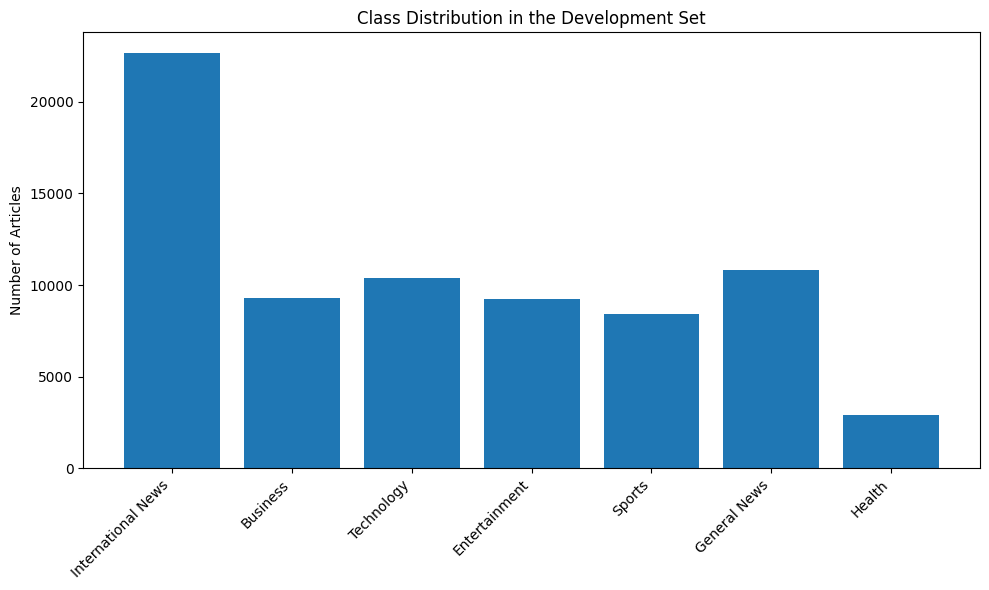

In [111]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(label_names, label_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Number of Articles')
plt.title('Class Distribution in the Development Set')
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

missing_ts = df['timestamp'].isna().sum()
print(f"Numero di valori mancanti nella colonna timestamp: {missing_ts}")

df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

df['year'] = df['timestamp'].dt.year

missing_year = df['year'].isna().sum()
print(f"Numero di timestamp non parsabili (year missing): {missing_year}")

label_year_dist = df.groupby(['year', 'label']).size().unstack(fill_value=0)

print("\nDistribuzione label per anno:")
print(label_year_dist)

label_year_pct = label_year_dist.div(label_year_dist.sum(axis=1), axis=0) * 100
print("\nPercentuale label per anno:")
print(label_year_pct)


Numero di valori mancanti nella colonna timestamp: 0
Numero di timestamp non parsabili (year missing): 25350

Distribuzione label per anno:
label      0     1     2     3     4     5    6
year                                           
2004.0  2558  1288   852  1741  1643  1730  490
2005.0   532   150    85   141   164   114   39
2006.0  3161  1105  1628   820   767   918  264
2007.0  6588  2820  4456  1975  1549  3303  710
2008.0  2038   953  1101   811   628   946  268

Percentuale label per anno:
label           0          1          2          3          4          5  \
year                                                                       
2004.0  24.830130  12.502427   8.270239  16.899631  15.948360  16.792856   
2005.0  43.428571  12.244898   6.938776  11.510204  13.387755   9.306122   
2006.0  36.488514  12.755397  18.792566   9.465543   8.853746  10.596791   
2007.0  30.783608  13.176954  20.821457   9.228541   7.237980  15.433858   
2008.0  30.214974  14.128984  16.323202

C:\Users\aless\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


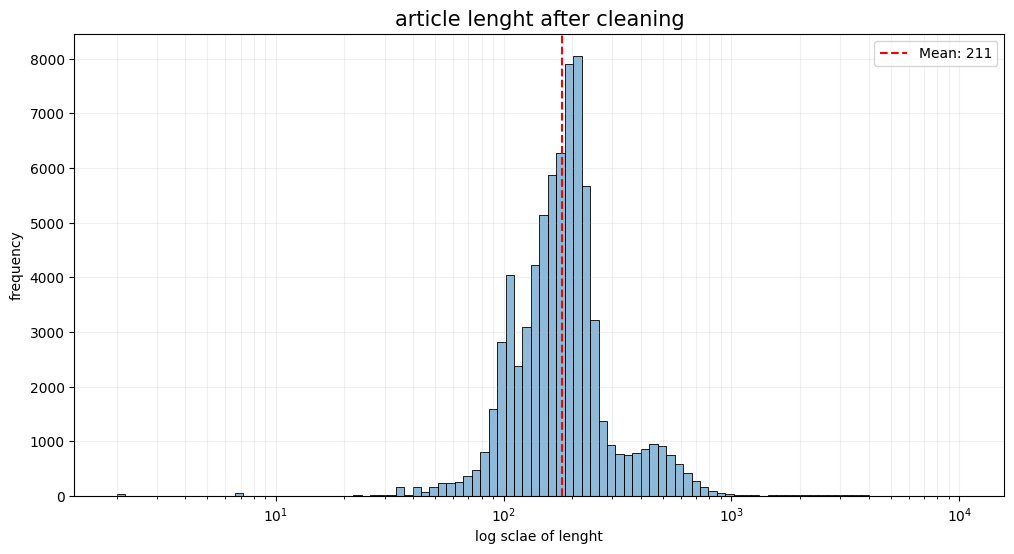

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

df = cleaner.fit_transform(df)

df['article_len'] = df['article'].fillna('').str.len()

plt.figure(figsize=(12, 6))
sns.histplot(df['article_len'], bins=100, kde=True, log_scale=(True, False))

plt.title('article lenght after cleaning', fontsize=15)
plt.xlabel('log sclae of lenght')
plt.ylabel('frequency')
plt.axvline(df['article_len'].median(), color='red', linestyle='--', label=f'Mean: {df["article_len"].mean():.0f}')
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

In [ ]:
top_long = df.sort_values(by='article_len', ascending=False).head(10)

for i, (idx, row) in enumerate(top_long.iterrows(), 1):
    print(f"{i}. LENGHT: {row['article_len']} - CATEGORY: {row['label']} ({category_map[row['label']]})")
    print("-" * 80)
    print(row['article'])
    print("\n" + "="*80 + "\n")

1. LENGHT: 10299 - CATEGORY: 2 (Technology)
--------------------------------------------------------------------------------
linux has been mentioned as a potentially leading platform for mobile devices for as long as there have been mobile devices however mobile linux is still largely missing in action the new crop of high visibility smart phones such as the the and the are based on microsoft s windows mobile the symbian and the aging palm os platforms so why are some in the mobile industry saying once again that linux is on the brink of becoming a significant platform for advanced mobile devices such as smart phones and why should anybody but industry insiders and geeks care linux has had peaks and troughs in the mobile industry but it s looking quite positive at the moment said matt lewis research director at arcchart the market research company recently issued a report entitled linux the new os celebrity one reason for that optimism according to mobile linux proponents is that this

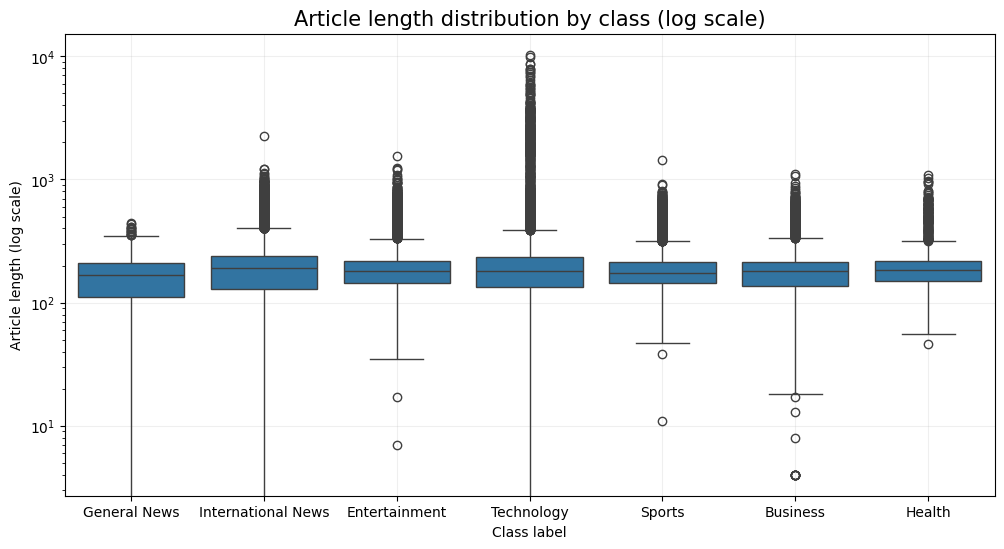

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
df['category'] = df['label'].map(category_map)

sns.boxplot(
    data=df,
    x='category',
    y='article_len',
)

plt.yscale('log')  
plt.title('Article length distribution by class (log scale)', fontsize=15)
plt.xlabel('Class label')
plt.ylabel('Article length (log scale)')
plt.grid(True, alpha=0.2)
plt.show()


In [116]:
# Prendiamo i 20 articoli più corti
top_short = df.sort_values(by='article_len', ascending=True).head(1000)

print(f"=== ANALISI CRITICA: I 20 ARTICOLI PIÙ CORTI ===\n")

for i, (idx, row) in enumerate(top_short.iterrows(), 1):
    print(f"{i}. [INDEX: {idx}] - LUNGHEZZA: {row['article_len']} - CATEGORIA: {row['label']} ({category_map[row['label']]})")
    print("-" * 40)
    print(f"CONTENUTO: '{row['article']}'")
    print("\n" + "="*40 + "\n")

=== ANALISI CRITICA: I 20 ARTICOLI PIÙ CORTI ===

1. [INDEX: 22206] - LUNGHEZZA: 0 - CATEGORIA: 2 (Technology)
----------------------------------------
CONTENUTO: ''


2. [INDEX: 49630] - LUNGHEZZA: 0 - CATEGORIA: 5 (General News)
----------------------------------------
CONTENUTO: ''


3. [INDEX: 44358] - LUNGHEZZA: 0 - CATEGORIA: 5 (General News)
----------------------------------------
CONTENUTO: ''


4. [INDEX: 47571] - LUNGHEZZA: 0 - CATEGORIA: 0 (International News)
----------------------------------------
CONTENUTO: ''


5. [INDEX: 29578] - LUNGHEZZA: 0 - CATEGORIA: 1 (Business)
----------------------------------------
CONTENUTO: ''


6. [INDEX: 1621] - LUNGHEZZA: 0 - CATEGORIA: 5 (General News)
----------------------------------------
CONTENUTO: ''


7. [INDEX: 8046] - LUNGHEZZA: 0 - CATEGORIA: 1 (Business)
----------------------------------------
CONTENUTO: ''


8. [INDEX: 266] - LUNGHEZZA: 0 - CATEGORIA: 0 (International News)
----------------------------------------
CONTENUT

# ANALISI SULLA DISTRIBUZIONE DEL VOCABOLARIO

In [117]:
X_raw = df[['source','title', 'article', 'page_rank']]
print(X_raw.shape)
y = df['label']
print(y.shape)
text_transformer = text_transformer1
cleaner = TextCleanerTransformer()
X = cleaner.fit_transform(X_raw)
print(X.shape)
# X = pd.DataFrame({'combined_text' : df['title'] + " " + df['article']})
X_transformed = text_transformer.fit_transform(X['combined_text'])
print(X_transformed.shape)
vocab = text_transformer.vocabulary_
print(f"Total Unique Words/N-grams: {len(vocab)}")

(73686, 4)
(73686,)
(73686, 6)
(73686, 60866)
Total Unique Words/N-grams: 60866


In [ ]:


weights = np.asarray(X_transformed.sum(axis=0)).flatten()
feature_names = text_transformer.get_feature_names_out()

# Create a DataFrame for easy viewing
word_dist = pd.DataFrame({'word': feature_names, 'weight': weights})
word_dist = word_dist.sort_values(by='weight', ascending=False)

print(X_transformed.shape)
print("Top 20 most influential words in the dataset:")
print(word_dist.head(40))


(73686, 60866)
Top 20 most influential words in the dataset:
                  word      weight
60261             year  658.638520
46931              say  519.893214
56208              two  480.987759
18589            first  448.331613
40906        president  448.228218
33627      moneyamount  447.130930
36866              one  430.028514
59745            world  425.630295
51169            state  423.514491
25979             iraq  417.543829
814                afp  409.981743
55938          tuesday  408.213611
58524        wednesday  403.754580
54390         thursday  401.752292
33468           monday  394.435369
10148          company  381.258874
20051           friday  380.855810
60613             york  368.256572
38667           people  366.644759
35530         new york  366.429331
12577              day  361.558768
42350             quot  361.192086
54629             time  360.502240
6869              bush  355.831710
58670             week  354.096179
36538         official  345.0

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=100)
X_significant = selector.fit_transform(X_transformed, y)

mask = selector.get_support() # Lista di Booleani
significant_words = np.array(text_transformer.get_feature_names_out())[mask]
print(f"Total Unique Words/N-grams: {len(significant_words)}")
print(significant_words)

Total Unique Words/N-grams: 100
['actor' 'afp' 'afp afp' 'apple' 'baseball' 'basketball' 'billion' 'blog'
 'bowl' 'breast' 'breast cancer' 'cancer' 'championship' 'coach' 'company'
 'computer' 'corp' 'cup' 'disease' 'doctor' 'drug' 'earnings' 'fda' 'film'
 'flu' 'flu vaccine' 'full story' 'game' 'google' 'health' 'healthday'
 'healthday healthday' 'healthday news' 'hollywood' 'inc' 'infection'
 'inning' 'internet' 'investor' 'iphone' 'iraq' 'latest detail' 'league'
 'market' 'mets' 'microsoft' 'minister' 'mobile' 'moneyamount'
 'moneyamount billion' 'movie' 'nba' 'new study' 'nfl' 'night' 'obesity'
 'oil' 'patient' 'patriot' 'percent' 'phone' 'player' 'point' 'president'
 'price' 'profit' 'quarter' 'quarterback' 'quarterly' 'read full'
 'red sox' 'researcher' 'reuters health' 'risk' 'sale' 'scored'
 'scored point' 'season' 'server' 'share' 'software' 'sox' 'space' 'sport'
 'sport network' 'stock' 'story latest' 'study' 'team' 'technology'
 'touchdown' 'treatment' 'user' 'vaccine' 'vict

# ANALISI SU TOP FEATURE

In [ ]:
num_transformer = StandardScaler()
source_transformer = OneHotEncoder(handle_unknown='ignore')



preprocessor = ColumnTransformer(
    transformers=[
        ('text', text_transformer1, 'combined_text'),
        # ('char', text_transformer_classic_char, 'combined_text2'),
        ('source', source_transformer, ['source'])
        
    ], remainder='drop'
)


pipeline_preprocessing = Pipeline([
    # ('cleaner', TextCleanerTransformer()),
    
    ('preprocessor', preprocessor)
    
])

In [121]:
print(X.shape)
X_transformed = preprocessor.fit_transform(X)

(73686, 6)


In [ ]:
# X_transformed = pipeline_preprocessing.fit_transform(X)

text_features = preprocessor.named_transformers_['text'].get_feature_names_out()

source_features = preprocessor.named_transformers_['source'].get_feature_names_out()

all_feature_names = np.concatenate([text_features, source_features])

In [ ]:
total_weights = np.asarray(X_transformed.sum(axis=0)).flatten()

top_features_df = pd.DataFrame({
    'feature': all_feature_names,
    'weight': total_weights
}).sort_values(by='weight', ascending=False)

print("Top 40 Feature assolute (Testo + Source):")
print(top_features_df.head(40))

Top 40 Feature assolute (Testo + Source):
                    feature        weight
62160          source_Yahoo  15523.000000
61811        source_Reuters  11061.000000
60965            source_BBC   7516.000000
61669            source_New   5836.000000
62123     source_Washington   3177.000000
61798        source_RedNova   2460.000000
61007         source_Boston   1752.000000
61980      source_Topix.Net   1325.000000
61039           source_CNET   1259.000000
61326       source_Guardian    977.000000
61041            source_CNN    906.000000
61622         source_Motley    837.000000
61805       source_Register    690.000000
61970           source_Time    666.000000
60261                  year    658.638520
60876            source_ABC    557.000000
61403      source_InfoWorld    553.000000
61266         source_Forbes    546.000000
61837            source_San    524.000000
46931                   say    519.893214
62146          source_Wired    513.000000
56208                   two    480

In [ ]:
from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(chi2, k=100)
X_significant = selector.fit_transform(X_transformed, y)

mask = selector.get_support() # Lista di Booleani
significant_words = np.array(all_feature_names)[mask]
print(f"Total Unique Words/N-grams: {len(significant_words)}")
print(significant_words)

Total Unique Words/N-grams: 100
['actor' 'afp' 'afp afp' 'apple' 'baseball' 'basketball' 'blog' 'breast'
 'breast cancer' 'cancer' 'championship' 'coach' 'company' 'corp' 'cup'
 'disease' 'drug' 'earnings' 'film' 'flu' 'flu vaccine' 'full story'
 'game' 'health' 'healthday' 'healthday healthday' 'healthday news'
 'hollywood' 'inc' 'inning' 'internet' 'investor' 'iraq' 'latest detail'
 'league' 'microsoft' 'mobile' 'moneyamount' 'new study' 'night' 'oil'
 'patient' 'percent' 'point' 'price' 'profit' 'quarterback' 'read full'
 'researcher' 'reuters health' 'risk' 'sale' 'scored' 'season' 'software'
 'sox' 'stock' 'story latest' 'study' 'team' 'technology' 'user' 'vaccine'
 'victory' 'web' 'win' 'yankee' 'york reuters' 'source_BBC' 'source_BCC'
 'source_Boston' 'source_CNET' 'source_CNN' 'source_CNN/SI'
 'source_CSMonitor' 'source_Computerworld' 'source_ESPN' 'source_Forbes'
 'source_Guardian' 'source_InfoWorld' 'source_Kiwibox' 'source_Medical'
 'source_Motley' 'source_New' 'source_Newsw

In [125]:
campioni = df[df['article'].str.contains('adlog', case=False, na=False)]
print(f"Trovate {len(campioni)} occorrenze di 'adlog'")
print(campioni['article'].head(3).values)

Trovate 0 occorrenze di 'adlog'
[]


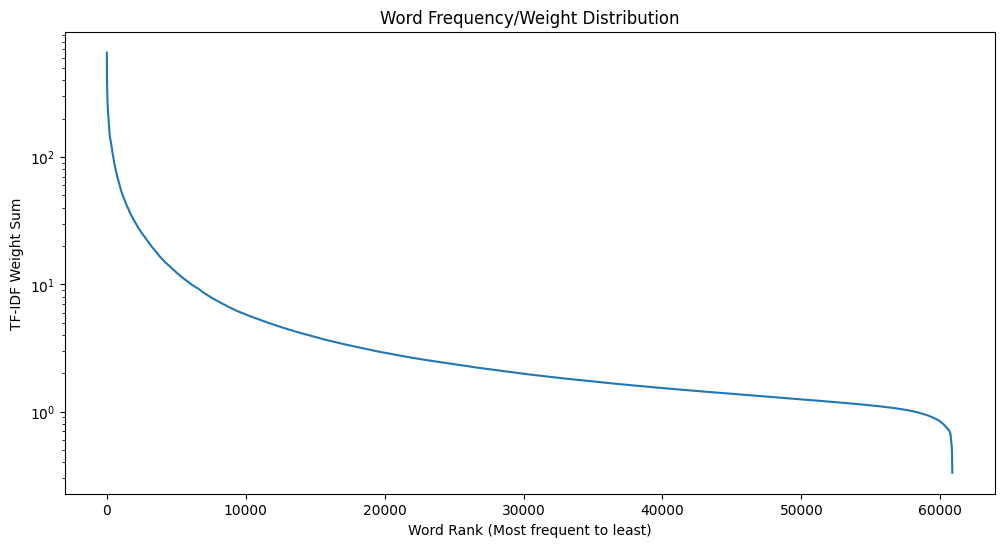

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(word_dist['weight'].values)
plt.title('Word Frequency/Weight Distribution')
plt.xlabel('Word Rank (Most frequent to least)')
plt.ylabel('TF-IDF Weight Sum')
plt.yscale('log')
plt.show()

# cheating distibuzione delle parole nell'evaluation

In [127]:
evaluation = pd.read_csv("winter_project_2026/evaluation.csv")

X_raw_eval = evaluation[['source','title', 'article', 'page_rank']]
y = df['label']

cleaner = TextCleanerTransformer()
X_eval = cleaner.fit_transform(X_raw_eval)
X_transformed_eval = text_transformer.fit_transform(X_eval['combined_text'])
vocab = text_transformer.vocabulary_
print(f"Total Unique Words/N-grams: {len(vocab)}")

Total Unique Words/N-grams: 16677


In [ ]:


weights = np.asarray(X_transformed_eval.sum(axis=0)).flatten()
feature_names = text_transformer.get_feature_names_out()

word_dist = pd.DataFrame({'word': feature_names, 'weight': weights})
word_dist = word_dist.sort_values(by='weight', ascending=False)

print("Top 20 most influential words in the dataset:")
print(word_dist.head(40))

Top 20 most influential words in the dataset:
              word      weight
16539         year  206.017277
12943          say  162.077435
15463          two  155.467426
9184   moneyamount  145.788269
10092          one  144.811223
5214         first  140.833931
11210    president  137.980537
7227          iraq  137.686467
14118        state  136.249660
16389        world  133.698352
15399      tuesday  128.576848
242            afp  126.918830
15007     thursday  123.654865
9152        monday  123.523423
16108    wednesday  123.518300
10602       people  120.199644
2798       company  119.655230
3479           day  119.104999
15065         time  118.876219
16137         week  116.224225
5608        friday  115.190624
1903          bush  113.837493
16608         york  109.115439
10025     official  108.930800
8722           may  108.718447
9701      new york  108.495691
11651         quot  107.543973
5995    government  107.512950
7915          last   98.925040
14462       sunday   98.

# ANALISIS ON ARTICLES

mean of articles is 210.78606519555953


(array([6.6835e+04, 6.0300e+03, 5.0300e+02, 5.2000e+01, 4.0000e+01,
        4.5000e+01, 4.2000e+01, 3.1000e+01, 1.9000e+01, 2.2000e+01,
        2.6000e+01, 6.0000e+00, 7.0000e+00, 1.0000e+00, 6.0000e+00,
        3.0000e+00, 2.0000e+00, 3.0000e+00, 1.0000e+00, 1.0000e+00,
        2.0000e+00, 2.0000e+00, 2.0000e+00, 1.0000e+00, 0.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 1.0000e+00]),
 array([    0. ,   343.3,   686.6,  1029.9,  1373.2,  1716.5,  2059.8,
         2403.1,  2746.4,  3089.7,  3433. ,  3776.3,  4119.6,  4462.9,
         4806.2,  5149.5,  5492.8,  5836.1,  6179.4,  6522.7,  6866. ,
         7209.3,  7552.6,  7895.9,  8239.2,  8582.5,  8925.8,  9269.1,
         9612.4,  9955.7, 10299. ]),
 <BarContainer object of 30 artists>)

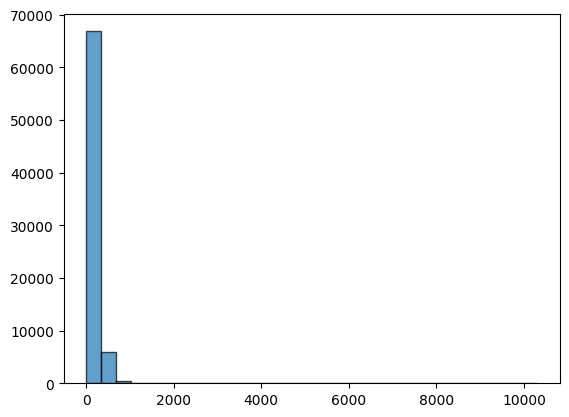

In [129]:
articles = df['article']
lenght = np.array([len(article) for article in articles])
print(f"mean of articles is {lenght.mean()}")
plt.hist(lenght , bins=30, edgecolor='black', alpha=0.7)

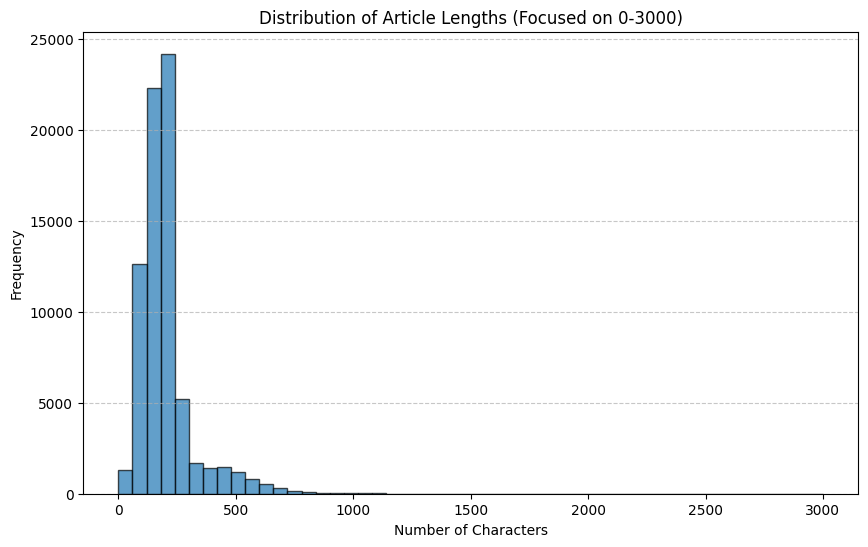

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(lenght, bins=50, range=(0, 3000), edgecolor='black', alpha=0.7)

plt.title("Distribution of Article Lengths (Focused on 0-3000)")
plt.xlabel("Number of Characters")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [131]:
df[df.groupby("article")["article"].transform("count") > 1]

,Id,source,title,article,page_rank,timestamp,label,year,combined_text,combined_text2,article_len
7,7,Yahoo,ramos why i quit sevilla for premiership spurs...,afp juande ramos has spoken for the first time...,5,2007-10-27 15:42:18,0,2007.0,ramos why i quit sevilla for premiership spurs...,afp juande ramos has spoken for the first time...,296
36,37,CNET,could youtube piratebay and file sharing boost...,blog the question of whether upcoming document...,3,2007-06-20 15:23:20,2,2007.0,could youtube piratebay and file sharing boost...,blog the question of whether upcoming document...,130
87,89,News,colombian official rebels planned to kill bush,on a href,5,2004-11-28 01:56:00,5,2004.0,colombian official rebels planned to kill bush...,on a href colombian official rebels planned to...,9
93,96,CNN,spice girls team up with victoria s secret,read full story for latest details,5,2007-10-18 13:32:25,5,2007.0,spice girls team up with victoria s secret rea...,read full story for latest details spice girls...,34
101,104,Search,search engine forums spotlight,links to the week s topics from search engine ...,5,2006-09-10 03:48:46,2,2006.0,search engine forums spotlight links to the we...,links to the week s topics from search engine ...,245
...,...,...,...,...,...,...,...,...,...,...,...
73373,79647,CNN,ancient village unearthed near stonehenge,read full story for latest details img src,5,2007-01-30 21:18:46,5,2007.0,ancient village unearthed near stonehenge read...,read full story for latest details img src anc...,42
73427,79709,Topix.Net,madrid bomb scare match rearranged,real madrid will play the final seven minutes ...,5,NaT,0,NaN,madrid bomb scare match rearranged real madrid...,real madrid will play the final seven minutes ...,187
73450,79733,Motley,these stocks beat paid search stocks,you may be surprised by the real leaders and l...,5,2008-01-23 00:30:21,1,2008.0,these stocks beat paid search stocks you may b...,you may be surprised by the real leaders and l...,53
73565,79866,CNN,second russian hospital hit by deadly fire,read full story for latest details img src,5,2006-12-10 18:04:10,5,2006.0,second russian hospital hit by deadly fire rea...,read full story for latest details img src sec...,42


In [132]:
df.duplicated(subset="article", keep=False)

0        False
1        False
2        False
3        False
4        False
         ...  
73681    False
73682    False
73683    False
73684    False
73685    False
Length: 73686, dtype: bool

In [133]:
total_duplicates = df.duplicated(subset="article").sum()
print(f"Total duplicated articles: {total_duplicates}")

Total duplicated articles: 815


# ANALISI ON SOURCE

In [ ]:
import matplotlib.pyplot as plt

nomi = df['source'].fillna('').apply(clean_text)
source_counts = nomi.value_counts()

plt.figure(figsize=(10, len(source_counts) * 0.3)) 

source_counts.plot(kind='barh', color='skyblue', edgecolor='black')

# 4. Abbelliamo il grafico
plt.title("Distribuzione di TUTTE le fonti (Source)")
plt.xlabel("Numero di articoli")
plt.ylabel("Nome della Fonte")
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()